Artifact directory ready: /content/artifacts/lstm_5fold_cv

Loaded datasets:
Train: 1429
Validation: 306
Train+Validation: 1735
Test: 307

Class distribution:
Train: {0: 726, 1: 703}
Validation: {0: 155, 1: 151}
Train+Validation: {0: 881, 1: 854}
Test: {0: 156, 1: 151}

STARTING FOLD 1/5
Best row for this fold:
{'fold': 1, 'lstm_units': 64, 'dropout_rate': 0.3, 'val_accuracy': 0.8587896253602305, 'val_precision': 0.9006622516556292, 'val_recall': 0.8, 'val_f1': 0.8473520249221184, 'val_roc_auc': np.float64(0.8972914589564639), 'epochs_trained': 4}

STARTING FOLD 2/5
Best row for this fold:
{'fold': 2, 'lstm_units': 64, 'dropout_rate': 0.3, 'val_accuracy': 0.8789625360230547, 'val_precision': 0.951048951048951, 'val_recall': 0.7953216374269005, 'val_f1': 0.8662420382165605, 'val_roc_auc': np.float64(0.9423179160021264), 'epochs_trained': 8}

STARTING FOLD 3/5
Best row for this fold:
{'fold': 3, 'lstm_units': 64, 'dropout_rate': 0.2, 'val_accuracy': 0.9048991354466859, 'val_precision': 0

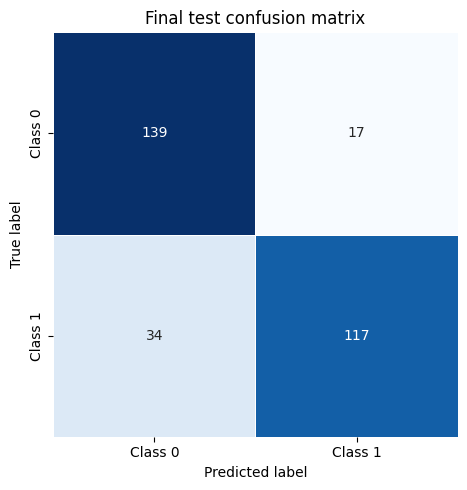

Final confusion matrix saved: /content/artifacts/lstm_5fold_cv/final_test_confusion_matrix.png


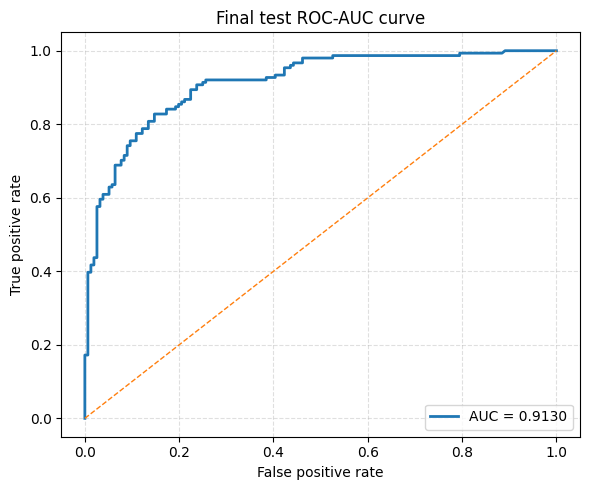

Final ROC curve saved: /content/artifacts/lstm_5fold_cv/final_test_roc_curve.png


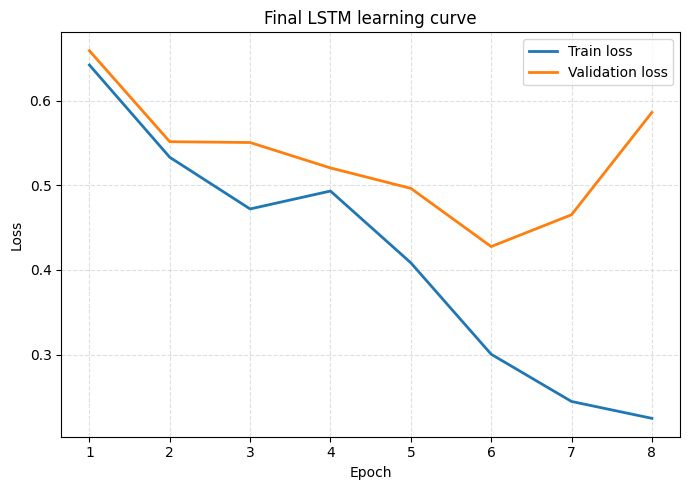

Final learning curve saved: /content/artifacts/lstm_5fold_cv/final_learning_curve.png

LSTM 5-fold CV experiment finished successfully.
You now have:
- 5-fold CV fold results
- all CV tuning results
- CV summary statistics
- parameter summary across folds
- final trained model (.keras)
- final tokenizer
- final test metrics JSON
- final classification report
- final test prediction CSV
- final training history CSV
- final confusion matrix PNG
- final ROC curve PNG
- final learning curve PNG


In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# =========================================================
# 0) SETTINGS
# =========================================================
RANDOM_SEED = 42

TRAIN_CSV = "/content/train.csv"
VAL_CSV = "/content/validation.csv"
TEST_CSV = "/content/test.csv"

TITLE_COL = "title"
TEXT_COL = "full_text"
LABEL_COL = "class_label"

MODEL_NAME = "lstm_5fold_cv"
ARTIFACT_DIR = f"/content/artifacts/{MODEL_NAME}"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ARTIFACT_DIR, "final_model.keras")
TOKENIZER_PATH = os.path.join(ARTIFACT_DIR, "final_tokenizer.json")

CV_RESULTS_PATH = os.path.join(ARTIFACT_DIR, "cv_fold_results.csv")
CV_TUNING_PATH = os.path.join(ARTIFACT_DIR, "cv_all_tuning_results.csv")
CV_SUMMARY_PATH = os.path.join(ARTIFACT_DIR, "cv_summary_statistics.csv")

FINAL_METRICS_PATH = os.path.join(ARTIFACT_DIR, "final_test_metrics.json")
FINAL_REPORT_PATH = os.path.join(ARTIFACT_DIR, "final_test_classification_report.txt")
FINAL_PREDICTIONS_PATH = os.path.join(ARTIFACT_DIR, "final_test_predictions.csv")
FINAL_CONFUSION_MATRIX_PATH = os.path.join(ARTIFACT_DIR, "final_test_confusion_matrix.png")
FINAL_ROC_PATH = os.path.join(ARTIFACT_DIR, "final_test_roc_curve.png")
FINAL_TRAINING_HISTORY_PATH = os.path.join(ARTIFACT_DIR, "final_training_history.csv")
FINAL_LEARNING_CURVE_PATH = os.path.join(ARTIFACT_DIR, "final_learning_curve.png")

# Tokenizer / sequence settings
MAX_NUM_WORDS = 30000
MAX_LEN = 256
EMBEDDING_DIM = 128

# Hyperparameter tuning grid
LSTM_UNITS_GRID = [64, 128]
DROPOUT_GRID = [0.2, 0.3]
BATCH_SIZE = 32
EPOCHS = 10
N_FOLDS = 5

# reproducibility
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Artifact directory ready:", ARTIFACT_DIR)


# =========================================================
# 1) HELPER FUNCTIONS
# =========================================================
def reset_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def load_df(path: str):
    df = pd.read_csv(path, encoding="utf-8")

    for col in [TITLE_COL, TEXT_COL, LABEL_COL]:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col} in {path}")

    df[TITLE_COL] = df[TITLE_COL].fillna("").astype(str)
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df


def make_text(df: pd.DataFrame):
    return (
        df[TITLE_COL].str.strip() + " " + df[TEXT_COL].str.strip()
    ).str.strip().tolist()


def get_prediction_group(true_label, pred_label):
    if true_label == 1 and pred_label == 1:
        return "TP"
    elif true_label == 0 and pred_label == 0:
        return "TN"
    elif true_label == 0 and pred_label == 1:
        return "FP"
    elif true_label == 1 and pred_label == 0:
        return "FN"
    return "UNKNOWN"


def evaluate_model(y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_score)
    report_text = classification_report(y_true, y_pred, digits=4, zero_division=0)

    metrics_dict = {
        "accuracy": float(acc),
        "precision": float(p),
        "recall": float(r),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc)
    }

    metrics_df = pd.DataFrame({
        "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
        "value": [acc, p, r, f1, roc_auc]
    })

    return metrics_dict, metrics_df, cm, report_text


def plot_confusion_matrix(cm, save_path):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"],
        cbar=False,
        square=True,
        linewidths=0.5
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Final test confusion matrix")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_roc_curve(y_true, y_score, roc_auc, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_score)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "--", linewidth=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Final test ROC-AUC curve")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_learning_curve(history_df, save_path):
    plt.figure(figsize=(7, 5))
    plt.plot(history_df["epoch"], history_df["loss"], label="Train loss", linewidth=2)
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Final LSTM learning curve")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def save_prediction_results(df_test, y_true, y_pred, y_prob, output_path):
    results_df = df_test[[TITLE_COL, TEXT_COL, LABEL_COL]].copy()
    results_df["pred_label"] = y_pred
    results_df["pred_prob"] = y_prob
    results_df["text_length"] = results_df[TEXT_COL].fillna("").astype(str).str.len()

    results_df["group"] = [
        get_prediction_group(true_label, pred_label)
        for true_label, pred_label in zip(y_true, y_pred)
    ]

    results_df = results_df[
        [
            TITLE_COL,
            TEXT_COL,
            LABEL_COL,
            "pred_label",
            "pred_prob",
            "group",
            "text_length"
        ]
    ]

    results_df.to_csv(output_path, index=False, encoding="utf-8")
    return results_df


def build_lstm_model(vocab_size, max_len, embedding_dim, lstm_units, dropout_rate):
    model = keras.Sequential([
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim),
        layers.SpatialDropout1D(dropout_rate),
        layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.0),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


# =========================================================
# 2) LOAD DATA
# =========================================================
train_df = load_df(TRAIN_CSV)
val_df = load_df(VAL_CSV)
test_df = load_df(TEST_CSV)

trainval_df = pd.concat([train_df, val_df], ignore_index=True)

print("\nLoaded datasets:")
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Train+Validation: {len(trainval_df)}")
print(f"Test: {len(test_df)}")

print("\nClass distribution:")
print("Train:", train_df[LABEL_COL].value_counts().to_dict())
print("Validation:", val_df[LABEL_COL].value_counts().to_dict())
print("Train+Validation:", trainval_df[LABEL_COL].value_counts().to_dict())
print("Test:", test_df[LABEL_COL].value_counts().to_dict())

X_trainval_text = make_text(trainval_df)
y_trainval = trainval_df[LABEL_COL].values

X_test_text = make_text(test_df)
y_test = test_df[LABEL_COL].values


# =========================================================
# 3) 5-FOLD CROSS-VALIDATION ON TRAIN+VALIDATION
# =========================================================
skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED
)

cv_fold_rows = []
cv_tuning_rows = []
best_params_per_fold = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval_text, y_trainval), start=1):
    print("\n" + "=" * 70)
    print(f"STARTING FOLD {fold_idx}/{N_FOLDS}")

    X_fold_train_text = [X_trainval_text[i] for i in train_idx]
    X_fold_val_text = [X_trainval_text[i] for i in val_idx]

    y_fold_train = y_trainval[train_idx]
    y_fold_val = y_trainval[val_idx]

    # tokenizer fit only on fold-train
    tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_fold_train_text)

    X_fold_train_seq = tokenizer.texts_to_sequences(X_fold_train_text)
    X_fold_val_seq = tokenizer.texts_to_sequences(X_fold_val_text)

    X_fold_train_pad = pad_sequences(X_fold_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
    X_fold_val_pad = pad_sequences(X_fold_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")

    vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)

    best_row = None

    for lstm_units in LSTM_UNITS_GRID:
        for dropout_rate in DROPOUT_GRID:
            tf.keras.backend.clear_session()
            reset_seeds()

            model = build_lstm_model(
                vocab_size=vocab_size,
                max_len=MAX_LEN,
                embedding_dim=EMBEDDING_DIM,
                lstm_units=lstm_units,
                dropout_rate=dropout_rate
            )

            early_stopping = EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            )

            history = model.fit(
                X_fold_train_pad,
                y_fold_train,
                validation_data=(X_fold_val_pad, y_fold_val),
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=[early_stopping],
                verbose=0,
                shuffle=False
            )

            val_prob = model.predict(X_fold_val_pad, verbose=0).ravel()
            val_pred = (val_prob >= 0.5).astype(int)

            acc = accuracy_score(y_fold_val, val_pred)
            p, r, f1, _ = precision_recall_fscore_support(
                y_fold_val,
                val_pred,
                average="binary",
                zero_division=0
            )
            roc_auc = roc_auc_score(y_fold_val, val_prob)

            row = {
                "fold": fold_idx,
                "lstm_units": lstm_units,
                "dropout_rate": dropout_rate,
                "val_accuracy": acc,
                "val_precision": p,
                "val_recall": r,
                "val_f1": f1,
                "val_roc_auc": roc_auc,
                "epochs_trained": len(history.history["loss"])
            }
            cv_tuning_rows.append(row)

            if best_row is None or row["val_f1"] > best_row["val_f1"]:
                best_row = row

    print("Best row for this fold:")
    print(best_row)

    best_params_per_fold.append(
        (int(best_row["lstm_units"]), float(best_row["dropout_rate"]))
    )

    # retrain best model for fold summary
    tf.keras.backend.clear_session()
    reset_seeds()

    best_model = build_lstm_model(
        vocab_size=vocab_size,
        max_len=MAX_LEN,
        embedding_dim=EMBEDDING_DIM,
        lstm_units=int(best_row["lstm_units"]),
        dropout_rate=float(best_row["dropout_rate"])
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = best_model.fit(
        X_fold_train_pad,
        y_fold_train,
        validation_data=(X_fold_val_pad, y_fold_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=0,
        shuffle=False
    )

    fold_prob = best_model.predict(X_fold_val_pad, verbose=0).ravel()
    fold_pred = (fold_prob >= 0.5).astype(int)

    fold_metrics, _, _, _ = evaluate_model(
        y_true=y_fold_val,
        y_pred=fold_pred,
        y_score=fold_prob
    )

    fold_row = {
        "fold": fold_idx,
        "best_lstm_units": int(best_row["lstm_units"]),
        "best_dropout_rate": float(best_row["dropout_rate"]),
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "epochs_trained": len(history.history["loss"]),
        **fold_metrics
    }
    cv_fold_rows.append(fold_row)

cv_results_df = pd.DataFrame(cv_fold_rows)
cv_results_df.to_csv(CV_RESULTS_PATH, index=False, encoding="utf-8")

cv_tuning_df = pd.DataFrame(cv_tuning_rows)
cv_tuning_df.to_csv(CV_TUNING_PATH, index=False, encoding="utf-8")

cv_summary_df = pd.DataFrame([{
    "num_folds": N_FOLDS,
    "accuracy_mean": cv_results_df["accuracy"].mean(),
    "accuracy_std": cv_results_df["accuracy"].std(ddof=1),
    "precision_mean": cv_results_df["precision"].mean(),
    "precision_std": cv_results_df["precision"].std(ddof=1),
    "recall_mean": cv_results_df["recall"].mean(),
    "recall_std": cv_results_df["recall"].std(ddof=1),
    "f1_mean": cv_results_df["f1_score"].mean(),
    "f1_std": cv_results_df["f1_score"].std(ddof=1),
    "roc_auc_mean": cv_results_df["roc_auc"].mean(),
    "roc_auc_std": cv_results_df["roc_auc"].std(ddof=1)
}])
cv_summary_df.to_csv(CV_SUMMARY_PATH, index=False, encoding="utf-8")

print("\n=== 5-FOLD CV RESULTS ===")
print(cv_results_df.sort_values("f1_score", ascending=False).to_string(index=False))

print("\n=== 5-FOLD CV SUMMARY ===")
print(cv_summary_df.to_string(index=False))


# =========================================================
# 4) CHOOSE FINAL HYPERPARAMETERS
# =========================================================
# izvēlamies parametrus ar labāko vidējo val_f1
param_summary = (
    cv_tuning_df
    .groupby(["lstm_units", "dropout_rate"], as_index=False)
    .agg(
        val_accuracy_mean=("val_accuracy", "mean"),
        val_precision_mean=("val_precision", "mean"),
        val_recall_mean=("val_recall", "mean"),
        val_f1_mean=("val_f1", "mean"),
        val_roc_auc_mean=("val_roc_auc", "mean"),
        epochs_trained_mean=("epochs_trained", "mean")
    )
    .sort_values(["val_f1_mean", "val_roc_auc_mean"], ascending=[False, False])
)

FINAL_PARAM_SUMMARY_PATH = os.path.join(ARTIFACT_DIR, "cv_param_summary.csv")
param_summary.to_csv(FINAL_PARAM_SUMMARY_PATH, index=False, encoding="utf-8")

best_final_row = param_summary.iloc[0]
final_lstm_units = int(best_final_row["lstm_units"])
final_dropout_rate = float(best_final_row["dropout_rate"])

print("\n=== PARAMETER SUMMARY ACROSS FOLDS ===")
print(param_summary.to_string(index=False))

print("\nChosen final hyperparameters:")
print({
    "lstm_units": final_lstm_units,
    "dropout_rate": final_dropout_rate
})


# =========================================================
# 5) FINAL TRAINING ON ALL TRAIN+VALIDATION
# =========================================================
tokenizer_final = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer_final.fit_on_texts(X_trainval_text)

X_trainval_seq = tokenizer_final.texts_to_sequences(X_trainval_text)
X_test_seq = tokenizer_final.texts_to_sequences(X_test_text)

X_trainval_pad = pad_sequences(X_trainval_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size_final = min(MAX_NUM_WORDS, len(tokenizer_final.word_index) + 1)

tf.keras.backend.clear_session()
reset_seeds()

final_model = build_lstm_model(
    vocab_size=vocab_size_final,
    max_len=MAX_LEN,
    embedding_dim=EMBEDDING_DIM,
    lstm_units=final_lstm_units,
    dropout_rate=final_dropout_rate
)

checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = final_model.fit(
    X_trainval_pad,
    y_trainval,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint, early_stopping],
    verbose=1,
    shuffle=False
)

final_model = keras.models.load_model(MODEL_PATH)

test_prob = final_model.predict(X_test_pad, verbose=0).ravel()
test_pred = (test_prob >= 0.5).astype(int)


# =========================================================
# 6) FINAL TEST EVALUATION
# =========================================================
metrics_dict, metrics_df, cm, report_text = evaluate_model(
    y_true=y_test,
    y_pred=test_pred,
    y_score=test_prob
)

metrics_dict["final_lstm_units"] = int(final_lstm_units)
metrics_dict["final_dropout_rate"] = float(final_dropout_rate)
metrics_dict["max_num_words"] = int(MAX_NUM_WORDS)
metrics_dict["max_len"] = int(MAX_LEN)
metrics_dict["embedding_dim"] = int(EMBEDDING_DIM)
metrics_dict["batch_size"] = int(BATCH_SIZE)
metrics_dict["epochs"] = int(EPOCHS)

print("\n=== FINAL TEST RESULTS ===")
print(metrics_df.to_string(index=False))

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

print("\nClassification report:")
print(report_text)


# =========================================================
# 7) SAVE TOKENIZER + METRICS + REPORT
# =========================================================
tokenizer_json = tokenizer_final.to_json()
with open(TOKENIZER_PATH, "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

with open(FINAL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=2)

with open(FINAL_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print("\nSaved final files:")
print(f"Model: {MODEL_PATH}")
print(f"Tokenizer: {TOKENIZER_PATH}")
print(f"Final metrics JSON: {FINAL_METRICS_PATH}")
print(f"Final classification report: {FINAL_REPORT_PATH}")


# =========================================================
# 8) SAVE TRAINING HISTORY
# =========================================================
history_df = pd.DataFrame(history.history)
history_df["epoch"] = np.arange(1, len(history_df) + 1)
history_df.to_csv(FINAL_TRAINING_HISTORY_PATH, index=False, encoding="utf-8")
print(f"Final training history saved: {FINAL_TRAINING_HISTORY_PATH}")


# =========================================================
# 9) SAVE FINAL PREDICTIONS
# =========================================================
results_df = save_prediction_results(
    df_test=test_df,
    y_true=y_test,
    y_pred=test_pred,
    y_prob=test_prob,
    output_path=FINAL_PREDICTIONS_PATH
)

print(f"\nFinal prediction file saved: {FINAL_PREDICTIONS_PATH}")
print("\nPrediction file preview:")
print(results_df.head().to_string(index=False))


# =========================================================
# 10) PLOT + SAVE FINAL CONFUSION MATRIX
# =========================================================
plot_confusion_matrix(cm, FINAL_CONFUSION_MATRIX_PATH)
print(f"Final confusion matrix saved: {FINAL_CONFUSION_MATRIX_PATH}")


# =========================================================
# 11) PLOT + SAVE FINAL ROC CURVE
# =========================================================
plot_roc_curve(
    y_true=y_test,
    y_score=test_prob,
    roc_auc=metrics_dict["roc_auc"],
    save_path=FINAL_ROC_PATH
)
print(f"Final ROC curve saved: {FINAL_ROC_PATH}")


# =========================================================
# 12) PLOT + SAVE FINAL LEARNING CURVE
# =========================================================
plot_learning_curve(history_df, FINAL_LEARNING_CURVE_PATH)
print(f"Final learning curve saved: {FINAL_LEARNING_CURVE_PATH}")


# =========================================================
# 13) FINAL MESSAGE
# =========================================================
print("\nLSTM 5-fold CV experiment finished successfully.")
print("You now have:")
print("- 5-fold CV fold results")
print("- all CV tuning results")
print("- CV summary statistics")
print("- parameter summary across folds")
print("- final trained model (.keras)")
print("- final tokenizer")
print("- final test metrics JSON")
print("- final classification report")
print("- final test prediction CSV")
print("- final training history CSV")
print("- final confusion matrix PNG")
print("- final ROC curve PNG")
print("- final learning curve PNG")

In [2]:
import shutil

source_folder = "/content/artifacts/lstm_5fold_cv"
output_zip = "/content/lstm_5fold_cv_results"

shutil.make_archive(output_zip, "zip", source_folder)

print("ZIP izveidots:", output_zip + ".zip")

ZIP izveidots: /content/lstm_5fold_cv_results.zip


In [3]:
import pandas as pd
import plotly.io as pio
import plotly.graph_objects as go

PREDICTIONS_FILE = "/content/artifacts/lstm_5fold_cv/final_test_predictions.csv"
SAVE_HTML = "/content/lstm_prediction_confidence_by_group_no_outliers.html"
STATS_PATH = "/content/lstm_prediction_confidence_by_group_stats.csv"

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(PREDICTIONS_FILE)

required_cols = ["group", "pred_prob"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

order = ["TP", "TN", "FP", "FN"]

# Keep only valid groups and non-null probabilities
df = df.copy()
df = df[df["group"].isin(order)]
df["pred_prob"] = pd.to_numeric(df["pred_prob"], errors="coerce")
df = df.dropna(subset=["pred_prob"])

# Make ordered categorical for stable plotting/statistics
df["group"] = pd.Categorical(df["group"], categories=order, ordered=True)
df = df.sort_values("group")

# Optional safety check
if df.empty:
    raise ValueError("No valid rows left after filtering. Check 'group' and 'pred_prob' columns.")

# =========================
# PLOTLY RENDERER
# =========================
# Good defaults for Colab / notebook / browser fallback
try:
    pio.renderers.default = "colab"
except Exception:
    try:
        pio.renderers.default = "notebook_connected"
    except Exception:
        pio.renderers.default = "browser"

# =========================
# PLOTLY BOXPLOT (NO OUTLIERS)
# =========================
fig = go.Figure()

for group_name in order:
    group_values = df.loc[df["group"] == group_name, "pred_prob"]
    if len(group_values) == 0:
        continue

    fig.add_trace(
        go.Box(
            y=group_values,
            name=group_name,
            boxpoints=False,   # equivalent to showfliers=False visual behavior
            marker_color="#007BFF",
            line_color="#007BFF"
        )
    )

fig.update_layout(
    title="LSTM Prediction Confidence by Outcome Group",
    template="plotly_white",
    xaxis_title="Outcome Group",
    yaxis_title="Prediction Confidence",
    showlegend=False
)

# Save interactive HTML
fig.write_html(SAVE_HTML, include_plotlyjs="cdn")

# Show figure
fig.show()

# =========================
# STATISTICS
# =========================
summary = (
    df.groupby("group", observed=False)["pred_prob"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        median="median",
        max="max"
    )
)

q1 = df.groupby("group", observed=False)["pred_prob"].quantile(0.25)
q3 = df.groupby("group", observed=False)["pred_prob"].quantile(0.75)

summary["q1"] = q1
summary["q3"] = q3
summary["iqr"] = summary["q3"] - summary["q1"]

summary = summary.reindex(order).reset_index()
summary.to_csv(STATS_PATH, index=False, encoding="utf-8")

print(summary.to_string(index=False))
print("\nSaved plot:", SAVE_HTML)
print("Saved stats:", STATS_PATH)

group  count     mean      std      min   median      max       q1       q3      iqr
   TP    117 0.913557 0.100794 0.532368 0.952521 0.977181 0.932505 0.959313 0.026808
   TN    139 0.178533 0.125713 0.062966 0.115081 0.485192 0.062968 0.286345 0.223378
   FP     17 0.836220 0.140413 0.562778 0.910825 0.960653 0.766191 0.933068 0.166877
   FN     34 0.315194 0.105171 0.062966 0.353878 0.449659 0.247633 0.387141 0.139508

Saved plot: /content/lstm_prediction_confidence_by_group_no_outliers.html
Saved stats: /content/lstm_prediction_confidence_by_group_stats.csv


basic group analysis

In [4]:
import pandas as pd

PREDICTIONS_FILE = "/content/artifacts/lstm_5fold_cv/final_test_predictions.csv"

df = pd.read_csv(PREDICTIONS_FILE)

print(df["group"].value_counts())
print(df["group"].value_counts(normalize=True).round(4))

group
TN    139
TP    117
FN     34
FP     17
Name: count, dtype: int64
group
TN    0.4528
TP    0.3811
FN    0.1107
FP    0.0554
Name: proportion, dtype: float64


In [5]:
# vispārliecinātākie FP
df[df["group"] == "FP"].sort_values("pred_prob", ascending=False).head(5)

# vissliktākie FN
df[df["group"] == "FN"].sort_values("pred_prob").head(5)

,title,full_text,class_label,pred_label,pred_prob,group,text_length
1,Dziesmu un Deju svētkos nebūs jādzer tikai vie...,"Organizatoru pārstāve Linda Ertmane skaidro, k...",1,0,0.062966,FN,934
208,Baidena un Trampa debates: puspatiesības un kl...,Straujiem soļiem tuvojas 5. novembrī paredzētā...,1,0,0.062967,FN,1240
25,ASV pludmalē izskalots milzu kalmārs?,"22. jūnijā sociālajā tīklā Facebook grupa ""Inc...",1,0,0.125941,FN,1794
73,"Šķeldas vagonu lieta - krava vesta uz Poliju, ...","Tātad, Indra. 302 km no Rīgas, tieši pie robež...",1,0,0.180614,FN,3156
157,ASV vēlēšanu pēcgarša: kā viedoklis ietekmē La...,Norādot uz pārkāpumiem balsu skaitīšanas un ba...,1,0,0.182575,FN,11311


In [6]:
print("FP:", df.index[df["group"] == "FP"].tolist())
print("FN:", df.index[df["group"] == "FN"].tolist())

FP: [64, 72, 76, 90, 102, 109, 133, 143, 174, 206, 216, 246, 248, 273, 282, 284, 298]
FN: [1, 25, 38, 43, 56, 57, 73, 83, 91, 93, 96, 106, 122, 131, 138, 139, 144, 154, 157, 161, 165, 169, 176, 182, 186, 190, 195, 208, 230, 236, 240, 263, 264, 289]
